# ML pipeline results

This notebook presents the saved outputs from the daily sales forecasting pipeline. It does not rerun model training.

The results are organized by the pipeline stages: validation, tuning, model comparison, forecasting, and actual-versus-predicted analysis.

## Setup

In [1]:
# import libraries
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

RESULTS_DIR = PROJECT_ROOT / "results"
print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Directory exists: {RESULTS_DIR.exists()}")

Results directory: /Users/Hardisk_WeiFeng/AIAP/machine-learning-pipeline-time-series/results
Directory exists: True


## Saved pipeline outputs

In [2]:
# list saved artifacts
artifact_paths = sorted(path for path in RESULTS_DIR.rglob("*") if path.is_file())
artifacts = pd.DataFrame({"artifact": [str(path.relative_to(RESULTS_DIR)) for path in artifact_paths]})
display(artifacts if not artifacts.empty else pd.DataFrame({"artifact": ["No saved results yet. Run src.ml_experiment first."]}))

,artifact
0,.DS_Store
1,.gitkeep
2,forecast.png
3,forecast_errors.csv
4,metrics.json
5,model_comparison.csv
6,model_comparison.png
7,models/baseline_naive_1_day.pkl
8,models/baseline_naive_1_week.pkl
9,models/selected_model.pkl


## Data validation before and after cleaning

In [3]:
# load validation results
validation_results = {}
for stage in ["before_cleaning", "after_cleaning"]:
    path = RESULTS_DIR / f"validation_{stage}.csv"
    if path.exists():
        validation_results[stage] = pd.read_csv(path)["success"].astype(bool)

if validation_results:
    validation_table = pd.DataFrame(validation_results)
    display(validation_table)
    validation_summary = pd.DataFrame({
        "checks_passed": validation_table.sum(axis=0),
        "checks_total": validation_table.notna().sum(axis=0),
    })
    validation_summary["all_checks_pass"] = validation_table.all(axis=0)
    display(validation_summary)
else:
    print("Validation results have not been saved yet.")

,before_cleaning,after_cleaning
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True
5,True,True
6,True,True
7,True,True
8,True,True
9,True,True


,checks_passed,checks_total,all_checks_pass
before_cleaning,22,26,False
after_cleaning,26,26,True


## Hyperparameter tuning

In [4]:
# load time-series cross-validation results
tuning_path = RESULTS_DIR / "tuning_results.csv"
if tuning_path.exists():
    tuning_results = pd.read_csv(tuning_path)
    display(tuning_results)
else:
    print("Tuning results have not been saved yet.")

,model,cv_rmse,best_params
0,random_forest,472.571254,"{'max_depth': 20, 'n_estimators': 200}"
1,knn,506.910852,"{'n_neighbors': 7, 'weights': 'distance'}"
2,linear_regression,533.184168,"{'fit_intercept': True, 'positive': True, 'tol..."
3,neural_network,942.232009,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 6..."


## Hyperparameter grid

In [5]:
# show the hyperparameter grid used for tuning
from time_series_pipeline.pipelines.model_training.nodes import MODEL_PARAM_GRIDS

grid_rows = [
    {
        "model": model_name,
        "parameter": parameter,
        "values": str(values),
    }
    for model_name, parameter_grid in MODEL_PARAM_GRIDS.items()
    for parameter, values in parameter_grid.items()
]
display(pd.DataFrame(grid_rows))

,model,parameter,values
0,linear_regression,fit_intercept,"[True, False]"
1,linear_regression,positive,"[False, True]"
2,linear_regression,tol,"[1e-06, 0.0001]"
3,random_forest,n_estimators,"[100, 200, 300, 500, 800]"
4,random_forest,max_depth,"[None, 20]"
5,neural_network,hidden_layer_sizes,"[(32,), (64,), (32, 16), (64, 32), (64, 32, 16..."
6,neural_network,alpha,"[0.0001, 0.001]"
7,knn,n_neighbors,"[1, 3, 7, 14, 28]"
8,knn,weights,"['uniform', 'distance']"


## Saved models and baseline comparison

In [6]:
# show saved model files and comparison metrics
models_dir = RESULTS_DIR / "models"
if models_dir.exists():
    display(pd.DataFrame({"saved_model": sorted(path.name for path in models_dir.glob("*.pkl"))}))

comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    display(comparison)
    best_row = comparison.iloc[0]
    print(f"Best test RMSE: {best_row['model']} ({best_row['test_rmse']:.2f})")
else:
    print("Model comparison has not been saved yet.")

,saved_model
0,baseline_naive_1_day.pkl
1,baseline_naive_1_week.pkl
2,selected_model.pkl
3,selected_model_name.pkl
4,tuned_models.pkl


,model,train_rmse,test_rmse
0,linear_regression,370.114508,456.800310
1,neural_network,268.923435,467.975269
2,random_forest,162.411360,599.323209
3,knn,0.000044,636.180417
4,naive_1_day,794.124088,864.142718
5,naive_1_week,1024.298885,1140.122088


Best test RMSE: linear_regression (456.80)


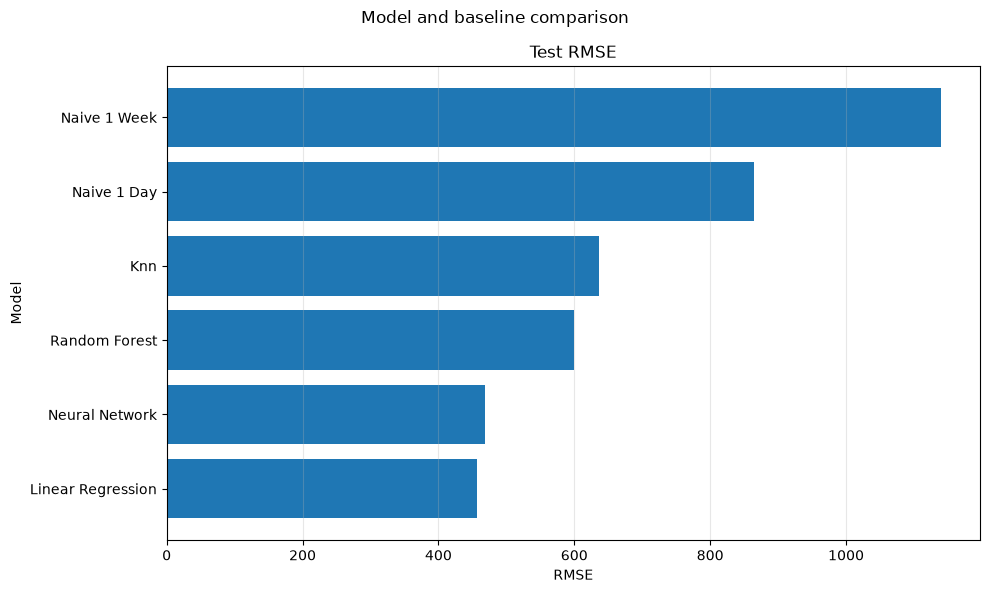

In [7]:
# create model and baseline RMSE comparison bar plot
comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    ordered_comparison = comparison.sort_values("test_rmse")
    labels = ordered_comparison["model"].str.replace("_", " ").str.title()
    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh(labels, ordered_comparison["test_rmse"])
    axis.set_title("Test RMSE")
    axis.set_xlabel("RMSE")
    axis.set_ylabel("Model")
    axis.grid(axis="x", alpha=0.3)
    figure.suptitle("Model and baseline comparison")
    figure.tight_layout()
    comparison_plot_path = RESULTS_DIR / "model_comparison.png"
    figure.savefig(comparison_plot_path, bbox_inches="tight")
    plt.show()
else:
    print("Model comparison results have not been saved yet.")

## Forecast results

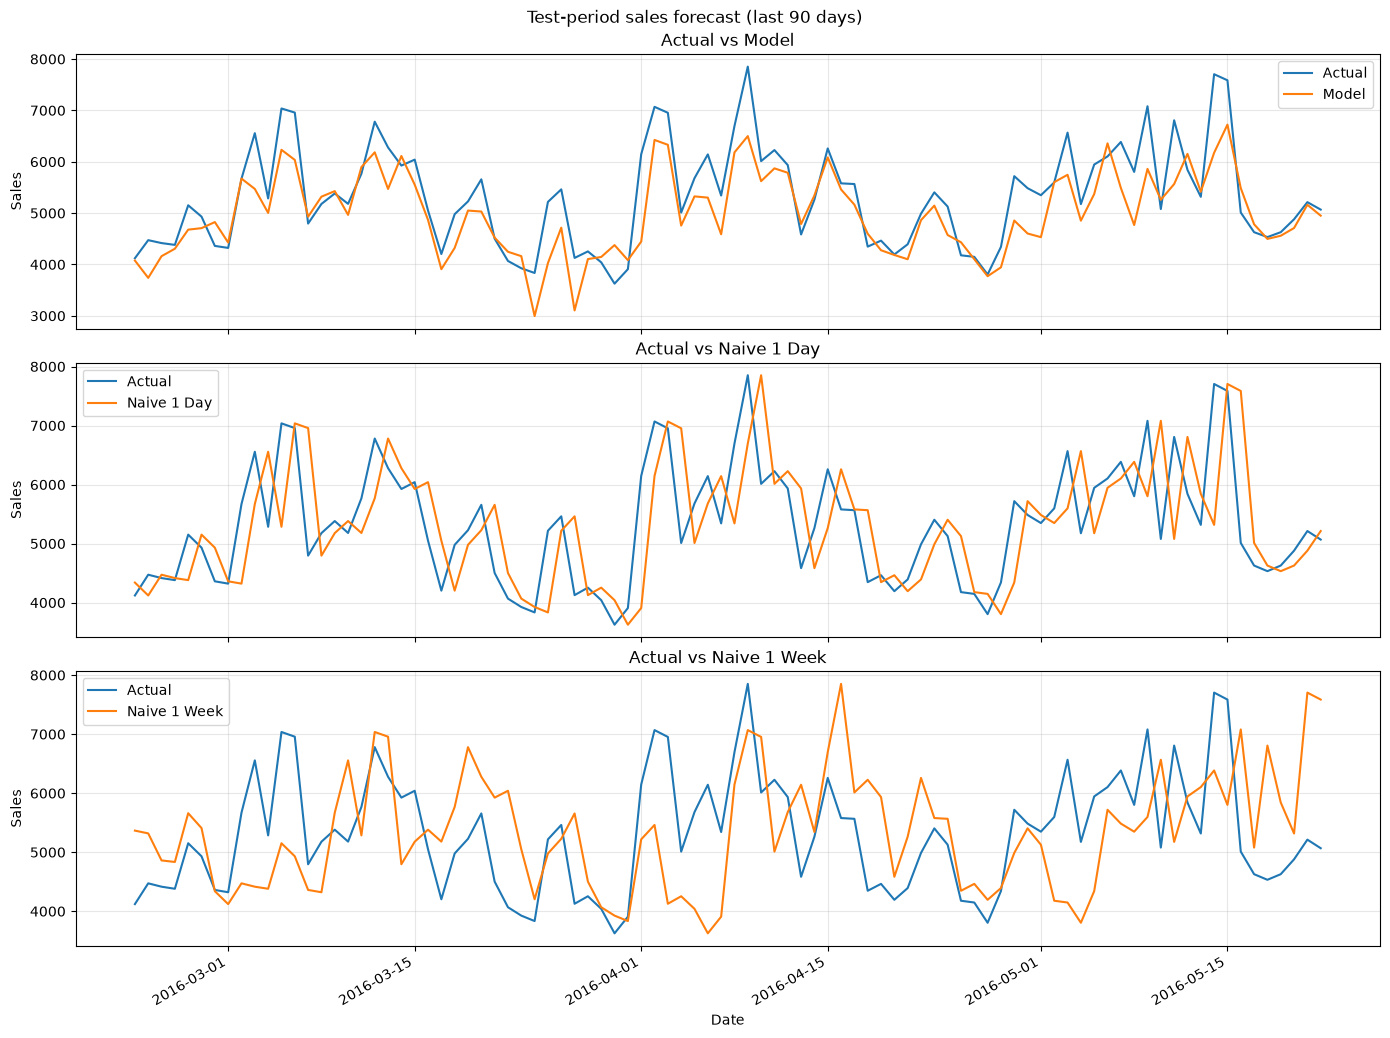

In [8]:
# plot actual sales, model forecasts, and both baselines
forecast_path = RESULTS_DIR / "forecast_errors.csv"
if forecast_path.exists():
    forecast = pd.read_csv(forecast_path, index_col=0, parse_dates=True).tail(90)
    forecast_columns = [
        ("prediction", "Model"),
        ("baseline_naive_1_day_prediction", "Naive 1 Day"),
        ("baseline_naive_1_week_prediction", "Naive 1 Week"),
    ]
    available_forecasts = [
        (column, label)
        for column, label in forecast_columns
        if column in forecast
    ]
    fig, axes = plt.subplots(
        len(available_forecasts),
        1,
        figsize=(14, 4 * len(available_forecasts)),
        sharex=True,
    )
    axes = [axes] if len(available_forecasts) == 1 else axes
    for axis, (forecast_column, forecast_label) in zip(axes, available_forecasts):
        axis.plot(forecast.index, forecast["actual"], label="Actual")
        axis.plot(forecast.index, forecast[forecast_column], label=forecast_label)
        axis.set_title(f"Actual vs {forecast_label}")
        axis.set_ylabel("Sales")
        axis.legend()
        axis.grid(alpha=0.3)
    axes[-1].set_xlabel("Date")
    fig.suptitle("Test-period sales forecast (last 90 days)")
    fig.tight_layout()
    fig.autofmt_xdate()
    plt.show()
else:
    print("Forecast results have not been saved yet.")

## Actual versus predicted sales

Pearson correlation (actual vs predicted): 0.8992
5th percentile error: -557 units
95th percentile error: 883 units


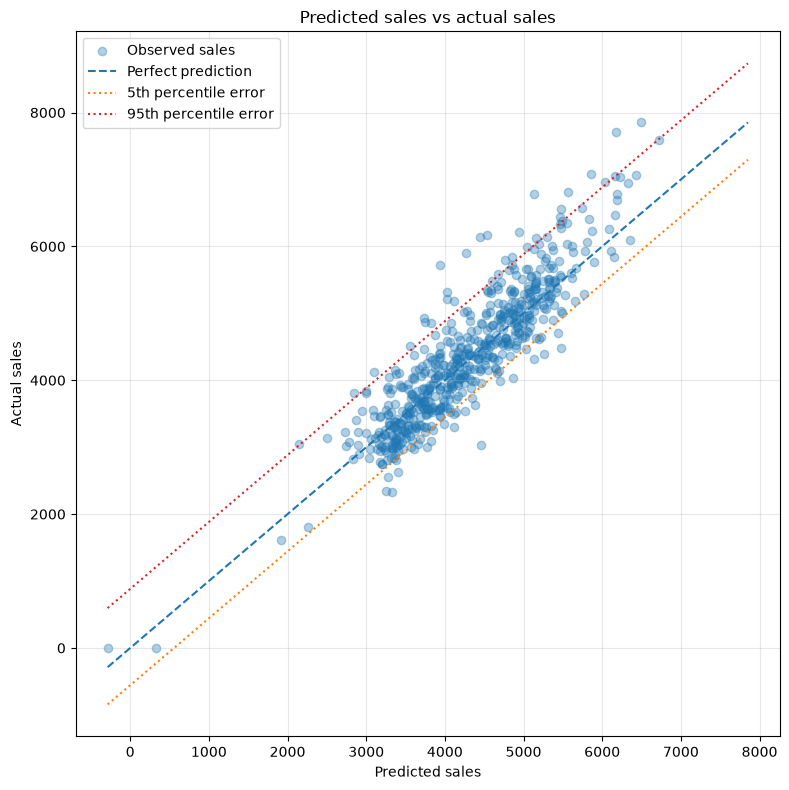

In [9]:
# plot predicted versus actual sales with empirical error bounds
forecast_path = RESULTS_DIR / "forecast_errors.csv"
if forecast_path.exists():
    forecast = pd.read_csv(forecast_path, index_col=0, parse_dates=True)
    residuals = forecast["actual"] - forecast["prediction"]
    lower_error = residuals.quantile(0.05, interpolation="lower")
    upper_error = residuals.quantile(0.95, interpolation="higher")
    pearson_correlation = forecast["actual"].corr(
        forecast["prediction"],
        method="pearson",
    )
    print(f"Pearson correlation (actual vs predicted): {pearson_correlation:.4f}")
    print(f"5th percentile error: {lower_error:.0f} units")
    print(f"95th percentile error: {upper_error:.0f} units")

    figure, axis = plt.subplots(figsize=(8, 8))
    axis.scatter(
        forecast["prediction"],
        forecast["actual"],
        alpha=0.35,
        label="Observed sales",
    )
    axis_min = min(forecast["actual"].min(), forecast["prediction"].min())
    axis_max = max(forecast["actual"].max(), forecast["prediction"].max())
    axis.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        label="Perfect prediction",
    )
    axis.plot(
        [axis_min, axis_max],
        [axis_min + lower_error, axis_max + lower_error],
        color="tab:orange",
        linestyle=":",
        label="5th percentile error",
    )
    axis.plot(
        [axis_min, axis_max],
        [axis_min + upper_error, axis_max + upper_error],
        color="tab:red",
        linestyle=":",
        label="95th percentile error",
    )
    axis.set_title("Predicted sales vs actual sales")
    axis.set_xlabel("Predicted sales")
    axis.set_ylabel("Actual sales")
    axis.legend()
    axis.grid(alpha=0.3)
    figure.tight_layout()
    figure.savefig(RESULTS_DIR / "predicted_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()
else:
    print("Forecast results have not been saved yet.")

## Summary

Use the validation tables to confirm the cleaning decisions, the tuning table to review model selection, the comparison table to assess improvement over both naive baselines, and the forecast and prediction-interval plots to review forecast alignment.